100%|██████████| 175/175 [10:13<00:00,  3.51s/it]


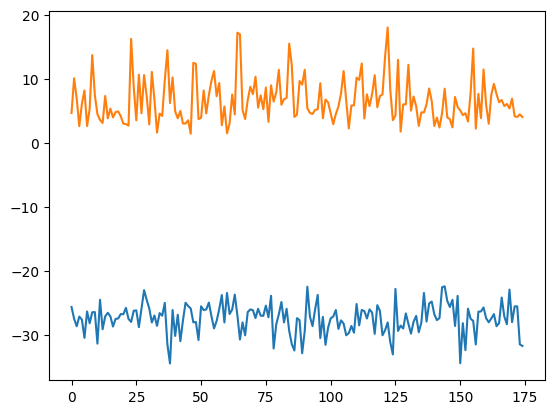

In [2]:
import numpy as np
import os
import essentia
import essentia.standard as es
import tqdm

import matplotlib.pyplot as plt
from pylab import plot, show, figure, imshow


SSL_DSET_PATH = "/Volumes/Saola's Drive/thesis/data/Diff-SSL-G-Comp"

DRY_PATH = 'processed_normalized'
WET_PATH = 'processed_ground_truth'

def load_audio_files(root_dir):
    audio_files = []
    for file in os.listdir(root_dir):
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root_dir, file))
    return audio_files

def load_audio(path):
    audio_st, sr, _, _, _, _ = es.AudioLoader(filename=path)()
    return audio_st, sr

def get_audio_stats(audio, sr):
    _, _, ebu_integrated, loudness_range = es.LoudnessEBUR128(hopSize=1024/sr, startAtZero=True)(audio)
    return ebu_integrated, loudness_range


files = load_audio_files(os.path.join(SSL_DSET_PATH, DRY_PATH))

stats = []
for file in tqdm.tqdm(files):
    audio, sr = load_audio(file)
    loudness, loudness_range = get_audio_stats(audio, sr)
    stats.append((loudness, loudness_range))
 
plot(stats)

In [38]:
files = load_audio_files(os.path.join(SSL_DSET_PATH, DRY_PATH))

peakstats = []
for file in tqdm.tqdm(files):
    audio, sr = load_audio(file)
    peak = np.max(np.absolute(audio))
    peakstats.append(peak)

100%|██████████| 175/175 [00:26<00:00,  6.72it/s]


In [ ]:
print(peakstats)

[np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32(0.2511884), np.float32

In [43]:
k = 30
top_idx = np.argsort(np_stats[:, 0])[-k:][::-1]
top_loudness = np_stats[top_idx]
files_array = np.array(files)
top_files = files_array[top_idx]

d = 10
top_d_idx = np.argsort(top_loudness[:, 1])[-d:][::-1]
top_d_loudness = top_loudness[top_d_idx]   
top_d_files = top_files[top_d_idx]

print(top_d_loudness)
print(top_d_files)

[[-23.03463745  10.55282784]
 [-25.205513    10.14929199]
 [-25.02567673   9.76595116]
 [-23.91552162   8.95453262]
 [-25.45764351   8.61070061]
 [-25.12249947   8.46343422]
 [-22.44111633   8.42574883]
 [-24.98106575   7.44207191]
 [-24.54237938   7.27855682]
 [-24.19542122   6.66007233]]
['/Volumes/Production Tools/coding_projs/THESIS/data_preprocesses/data/Diff-SSL-G-Comp/processed_normalized/NosPalpitants_UnmasteredWAV.wav'
 '/Volumes/Production Tools/coding_projs/THESIS/data_preprocesses/data/Diff-SSL-G-Comp/processed_normalized/AncoraQui_UnmasteredWAV.wav'
 '/Volumes/Production Tools/coding_projs/THESIS/data_preprocesses/data/Diff-SSL-G-Comp/processed_normalized/SongForJohn_UnmasteredWAV.wav'
 '/Volumes/Production Tools/coding_projs/THESIS/data_preprocesses/data/Diff-SSL-G-Comp/processed_normalized/Air_UnmasteredWAV.wav'
 '/Volumes/Production Tools/coding_projs/THESIS/data_preprocesses/data/Diff-SSL-G-Comp/processed_normalized/OpenFire_UnmasteredWAV.wav'
 '/Volumes/Production Too